# 미션12 문제 정의

1. **분석 배경 및 목표**

- 페르소나: 자전거 대여 시스템 운영 담당자 임무 수행함.

- 최종 목표: 대여 패턴 분석을 통한 자전거 배치 및 운영 전략 최적화임.

- 핵심 과제: 다양한 변수(날씨, 시간 등)를 활용하여 미래의 대여 수요를 정확히 예측하는 모델 개발함.

2. **해결 과제 (Objective)**

- 예측 대상: 특정 시간대의 총 자전거 대여 수(count)임.

- 분석 방향: 시간대별, 날씨별, 계절별 대여 패턴의 차이 규명함.

- 주말과 평일의 수요 차이 등 비즈니스 관점의 인사이트 도출함.

- 예측 모델을 기반으로 한 실질적인 운영 전략 제안함.

3. **평가 지표 (RMSLE)**

- 정의: 예측값과 실제값의 차이를 로그 변환하여 계산하는 지표임.

- 사용 이유: 수치적 차이보다 '몇 배 틀렸는지'에 대한 비율을 중요하게 평가함.

- 대여량이 적은 구간과 많은 구간의 오차를 고르게 반영함.

- 운영 관점에서 과도하게 자전거를 준비하거나 부족하게 준비하는 리스크 관리 목적임.

4. **데이터 및 제출물**

- train.csv: 학습용 데이터 (대여량 count 포함됨).

- test.csv: 테스트용 데이터 (수요 예측 대상임).

- 제출물 : 코랩 노트북(전처리, 모델링, 성능 평가 전 과정 포함함), 보고서(가설 설정, 분석 전개, 최종 인사이트 정리함)

# 분석 환경 설정

In [168]:
# 개발환경 세팅하기
# ▶ 한글 폰트 다운로드
!sudo apt-get install -y fonts-nanum
!sudo fc-cache -fv
!rm ~/.cache/matplotlib -rf

!apt-get update -qq
!apt-get install fonts-nanum* -qq

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings(action='ignore')

path = '/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf' # 나눔 고딕
font_name = fm.FontProperties(fname=path, size=10).get_name() # 기본 폰트 사이즈 : 10
plt.rc('font', family=font_name)

fm.fontManager.addfont(path)

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 104 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 39 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype

In [169]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# 코랩에서 그래프가 바로 보이게 설정
%matplotlib inline
# Pandas 보기 옵션
pd.set_option('display.max_columns',100)

In [171]:
# 경로 지정
import os
path = "/content/drive/MyDrive/[2025] CodeIt/[Sprint]mission/mission12/data/"
os.chdir(path)

In [172]:
ls

test.csv  train.csv


# 원본 데이터 살피기

## 1. train 데이터

In [173]:
# train 데이터 크기 확인
train = pd.read_csv('train.csv')
print(f"Train Data Shape: {train.shape}")

Train Data Shape: (10886, 12)


In [174]:
train.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count'],
      dtype='object')

In [175]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    10886 non-null  object 
 1   season      10886 non-null  int64  
 2   holiday     10886 non-null  int64  
 3   workingday  10886 non-null  int64  
 4   weather     10886 non-null  int64  
 5   temp        10886 non-null  float64
 6   atemp       10886 non-null  float64
 7   humidity    10886 non-null  int64  
 8   windspeed   10886 non-null  float64
 9   casual      10886 non-null  int64  
 10  registered  10886 non-null  int64  
 11  count       10886 non-null  int64  
dtypes: float64(3), int64(8), object(1)
memory usage: 1020.7+ KB


In [176]:
train['datetime'] = pd.to_datetime(train['datetime'])

In [177]:
train.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0
casual,0


In [178]:
train.describe()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
count,10886,10886.000000,10886.000000,10886.000000,10886.000000,10886.00000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000,10886.000000
mean,2011-12-27 05:56:22.399411968,2.506614,0.028569,0.680875,1.418427,20.23086,23.655084,61.886460,12.799395,36.021955,155.552177,191.574132
min,2011-01-01 00:00:00,1.000000,0.000000,0.000000,1.000000,0.82000,0.760000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-02 07:15:00,2.000000,0.000000,0.000000,1.000000,13.94000,16.665000,47.000000,7.001500,4.000000,36.000000,42.000000
50%,2012-01-01 20:30:00,3.000000,0.000000,1.000000,1.000000,20.50000,24.240000,62.000000,12.998000,17.000000,118.000000,145.000000
75%,2012-07-01 12:45:00,4.000000,0.000000,1.000000,2.000000,26.24000,31.060000,77.000000,16.997900,49.000000,222.000000,284.000000
max,2012-12-19 23:00:00,4.000000,1.000000,1.000000,4.000000,41.00000,45.455000,100.000000,56.996900,367.000000,886.000000,977.000000
std,NaN,1.116174,0.166599,0.466159,0.633839,7.79159,8.474601,19.245033,8.164537,49.960477,151.039033,181.144454


## train 좀더 살필 것들
- workingday :  평균(0.68)이 중앙값(1)보다 작음. 중앙값과 최댓값이 동일(1) -> 업무일에 데이터가 1에 쏠려있음 -> 평일 출퇴근 예측
- casual : 중앙값 17, 평균 36, 75% 49, 최대값 367 -> right skewed
- registered : 중앙값 118, 평균 155, 75% 222, 최댓값 886 -> right skewed
- count : 중앙값 145, 평균 191, 75% 284, 최댓값 977 -> right skewed

- 이용자는 casual과 registerd로 나뉘어져 있음
- casual + resigered = count

## 2. test 데이터

In [179]:
# test 데이터 크기 확인
test = pd.read_csv('test.csv')
print(f"Test Data Shape: {test.shape}")

Test Data Shape: (6493, 9)


In [180]:
test.columns

Index(['datetime', 'season', 'holiday', 'workingday', 'weather', 'temp',
       'atemp', 'humidity', 'windspeed'],
      dtype='object')

In [181]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   datetime    6493 non-null   object 
 1   season      6493 non-null   int64  
 2   holiday     6493 non-null   int64  
 3   workingday  6493 non-null   int64  
 4   weather     6493 non-null   int64  
 5   temp        6493 non-null   float64
 6   atemp       6493 non-null   float64
 7   humidity    6493 non-null   int64  
 8   windspeed   6493 non-null   float64
dtypes: float64(3), int64(5), object(1)
memory usage: 456.7+ KB


In [182]:
test['datetime'] = pd.to_datetime(test['datetime'])

In [183]:
test.isnull().sum()

,0
datetime,0
season,0
holiday,0
workingday,0
weather,0
temp,0
atemp,0
humidity,0
windspeed,0


In [184]:
test.describe()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed
count,6493,6493.000000,6493.000000,6493.000000,6493.000000,6493.000000,6493.000000,6493.000000,6493.000000
mean,2012-01-13 09:27:47.765285632,2.493300,0.029108,0.685815,1.436778,20.620607,24.012865,64.125212,12.631157
min,2011-01-20 00:00:00,1.000000,0.000000,0.000000,1.000000,0.820000,0.000000,16.000000,0.000000
25%,2011-07-22 15:00:00,2.000000,0.000000,0.000000,1.000000,13.940000,16.665000,49.000000,7.001500
50%,2012-01-20 23:00:00,3.000000,0.000000,1.000000,1.000000,21.320000,25.000000,65.000000,11.001400
75%,2012-07-20 17:00:00,3.000000,0.000000,1.000000,2.000000,27.060000,31.060000,81.000000,16.997900
max,2012-12-31 23:00:00,4.000000,1.000000,1.000000,4.000000,40.180000,50.000000,100.000000,55.998600
std,NaN,1.091258,0.168123,0.464226,0.648390,8.059583,8.782741,19.293391,8.250151


# 데이터 가공

In [185]:
top3_datetime = train.groupby('datetime')['count'].sum().reset_index()
top3_datetime = top3_datetime.sort_values(by='count', ascending=False).head(3)
print(top3_datetime)

                datetime  count
9345 2012-09-12 18:00:00    977
9320 2012-09-11 17:00:00    970
9297 2012-09-10 18:00:00    968


In [186]:
daily_counts = train.groupby(train['datetime'].dt.date)['count'].sum().reset_index()
daily_counts['datetime'] = pd.to_datetime(daily_counts['datetime'])
top3_dates = daily_counts.sort_values(by='count', ascending=False).head(3)
print(top3_dates)

      datetime  count
394 2012-09-15   8714
322 2012-05-19   8294
388 2012-09-09   8227


In [187]:
# datetime 쪼개기
def split_datetime(df):
    df['datetime'] = pd.to_datetime(df['datetime'])
    df['year'] = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    df['day'] = df['datetime'].dt.day
    df['hour'] = df['datetime'].dt.hour
    df['dayofweek'] = df['datetime'].dt.dayofweek
    return df

train = split_datetime(train)
test = split_datetime(test)

In [188]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[ns]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
 12  year        10886 non-null  int32         
 13  month       10886 non-null  int32         
 14  day         10886 non-null  int32         
 15  hour        10886 non-null  int32         
 16  dayofweek   10886 non-

In [189]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6493 entries, 0 to 6492
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    6493 non-null   datetime64[ns]
 1   season      6493 non-null   int64         
 2   holiday     6493 non-null   int64         
 3   workingday  6493 non-null   int64         
 4   weather     6493 non-null   int64         
 5   temp        6493 non-null   float64       
 6   atemp       6493 non-null   float64       
 7   humidity    6493 non-null   int64         
 8   windspeed   6493 non-null   float64       
 9   year        6493 non-null   int32         
 10  month       6493 non-null   int32         
 11  day         6493 non-null   int32         
 12  hour        6493 non-null   int32         
 13  dayofweek   6493 non-null   int32         
dtypes: datetime64[ns](1), float64(3), int32(5), int64(5)
memory usage: 583.5 KB


# EDA

## 시간대, 요일 등 시계열 기준

In [190]:
day_names = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
train['dayofweek'] = train['dayofweek'].map(day_names)
test['dayofweek'] = test['dayofweek'].map(day_names)
print("Train dayofweek after mapping:\n", train['dayofweek'].value_counts())
print("\nTest dayofweek after mapping:\n", test['dayofweek'].value_counts())

Train dayofweek after mapping:
 dayofweek
Sat    1584
Sun    1579
Thu    1553
Mon    1551
Wed    1551
Tue    1539
Fri    1529
Name: count, dtype: int64

Test dayofweek after mapping:
 dayofweek
Fri    958
Sat    928
Mon    928
Wed    924
Sun    923
Thu    918
Tue    914
Name: count, dtype: int64


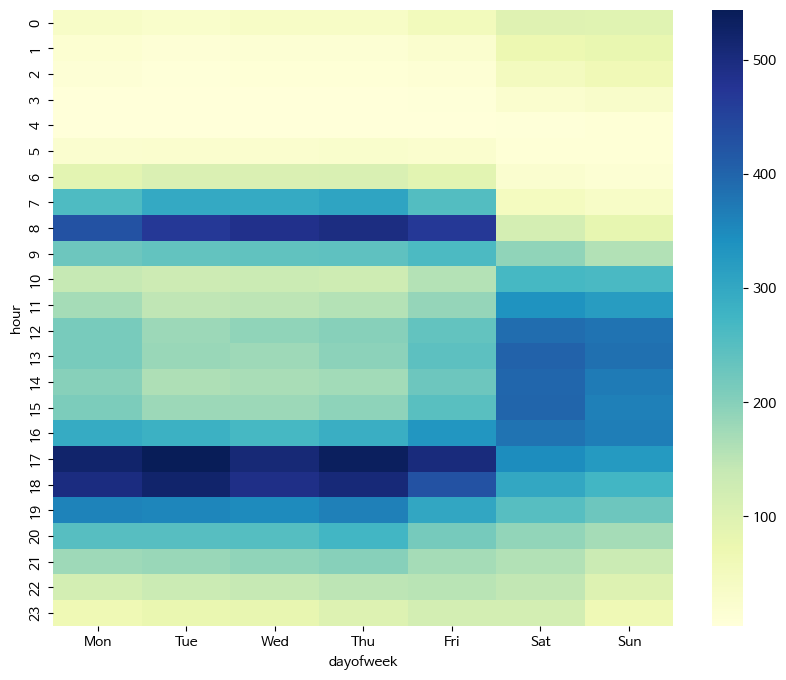

In [191]:
# 시간과 요일 평균 대여량 히트맵
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
pivot = train.pivot_table(index='hour', columns='dayofweek', values='count', aggfunc='mean')
pivot = pivot[day_order] # Reorder columns
plt.figure(figsize=(10, 8))
sns.heatmap(pivot, annot=False, cmap='YlGnBu')
plt.show()

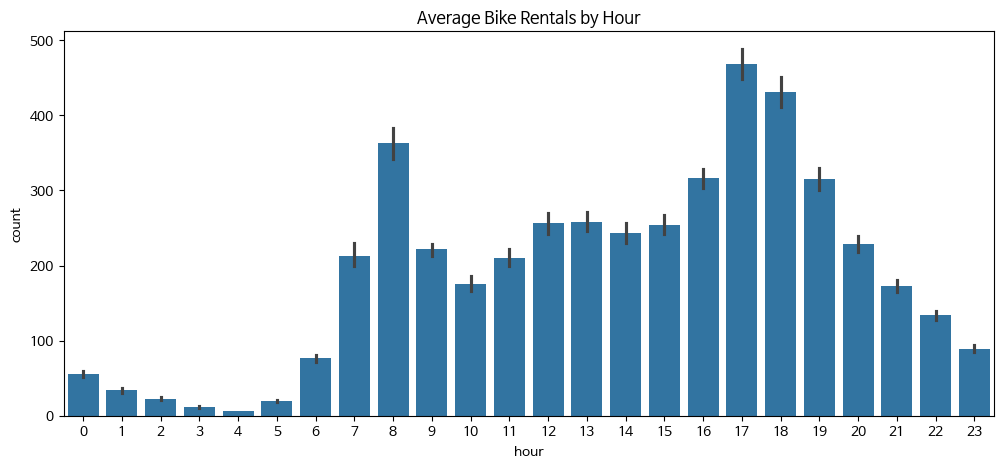

In [192]:
# 시간대별 평균 대여량 시각화
plt.figure(figsize=(12, 5))
sns.barplot(data=train, x='hour', y='count')
plt.title('Average Bike Rentals by Hour')
plt.show()

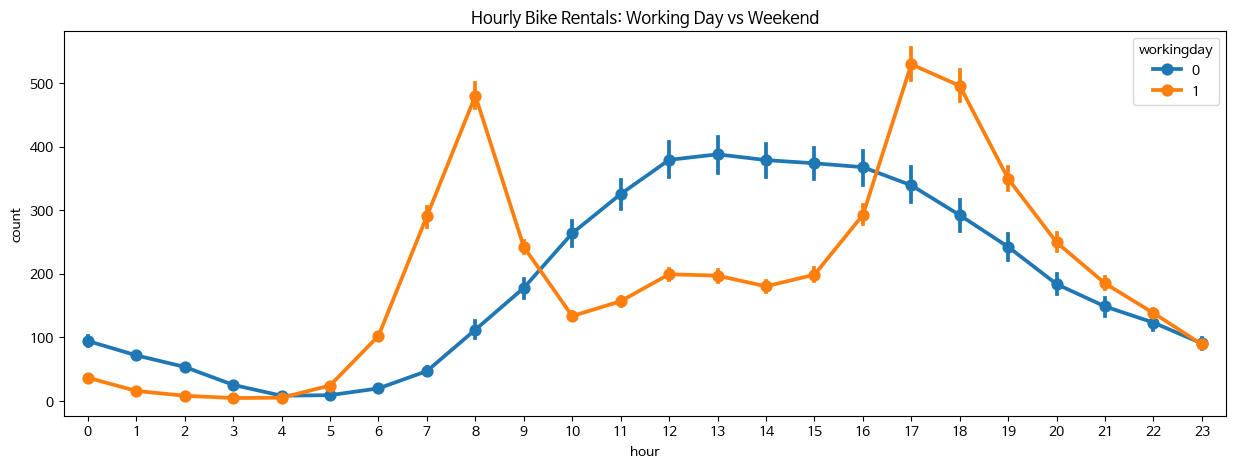

In [193]:
# 요일별(평일 1, 주말 0) 시간대별 패턴 비교
plt.figure(figsize=(15, 5))
sns.pointplot(data=train, x='hour', y='count', hue='workingday')
plt.title('Hourly Bike Rentals: Working Day vs Weekend')
plt.show()

## 계절, 온도 등 날씨 기준

In [194]:
# 날씨별 주요 기상 지표 평균 확인
weather_profile = train.groupby('weather')[['temp', 'atemp', 'humidity', 'windspeed']].mean()
weather_profile

,temp,atemp,humidity,windspeed
weather,,,,
1,20.557122,23.994126,56.716769,12.892542
2,19.614608,23.072414,69.100565,12.179905
3,19.546356,22.753091,81.341094,14.071248
4,8.200000,11.365000,86.000000,6.003200


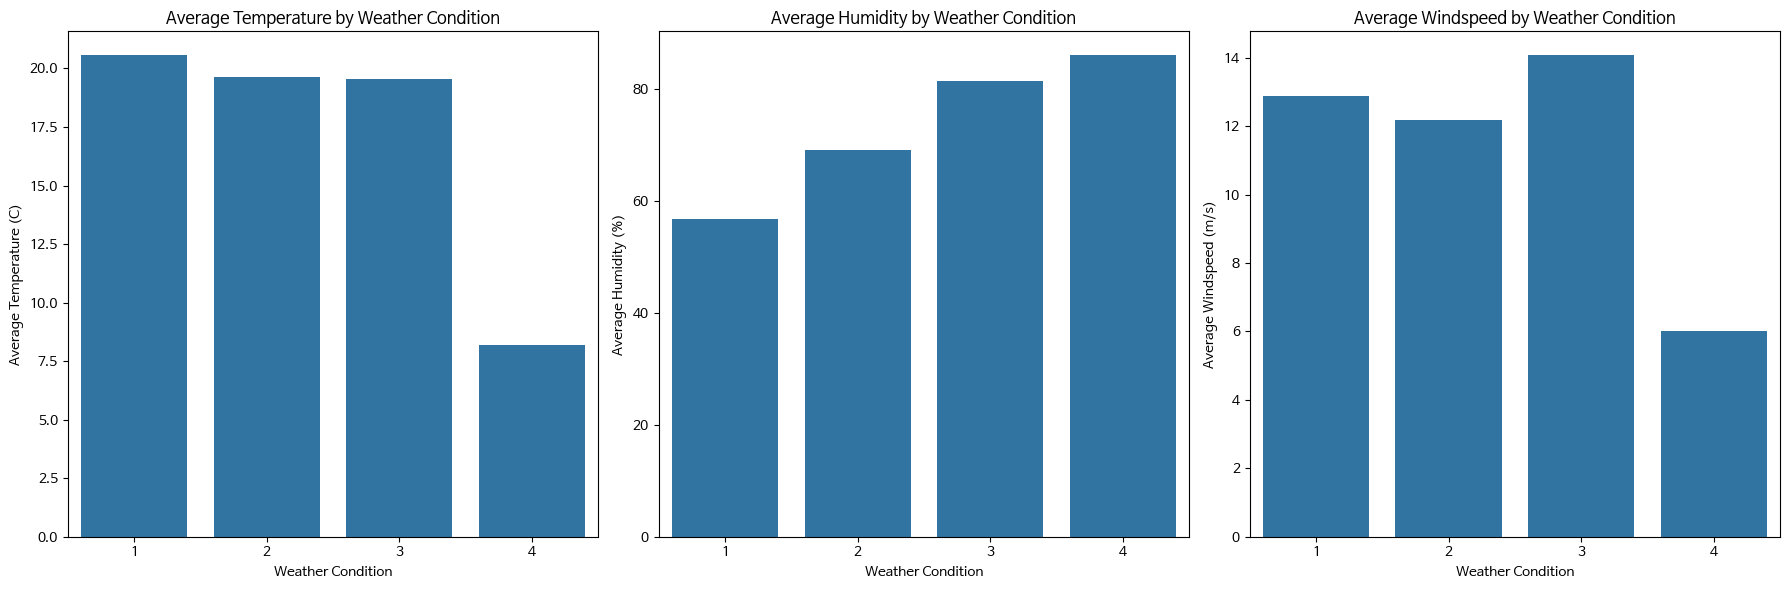

In [195]:
# 시각화
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

sns.barplot(x=weather_profile.index, y=weather_profile['temp'], ax=axes[0])
axes[0].set_title('Average Temperature by Weather Condition')
axes[0].set_xlabel('Weather Condition')
axes[0].set_ylabel('Average Temperature (C)')

sns.barplot(x=weather_profile.index, y=weather_profile['humidity'], ax=axes[1])
axes[1].set_title('Average Humidity by Weather Condition')
axes[1].set_xlabel('Weather Condition')
axes[1].set_ylabel('Average Humidity (%)')

sns.barplot(x=weather_profile.index, y=weather_profile['windspeed'], ax=axes[2])
axes[2].set_title('Average Windspeed by Weather Condition')
axes[2].set_xlabel('Weather Condition')
axes[2].set_ylabel('Average Windspeed (m/s)')

plt.tight_layout()
plt.show()

###
*   **Weather 1 (맑음)**: 평균적으로 가장 쾌적한 온도와 낮은 습도
*   **Weather 2 (흐림, 안개)**: 습도가 다소 증가하지만, 온도와 풍속은 Weather 1과 큰 차이 없음
*   **Weather 3 (가벼운 눈/비, 천둥)**: 습도가 가장 높고, 온도는 낮아지며, 풍속은 약간 증가하는 경향
*   **Weather 4 (폭우, 우박, 폭설)**: 매우 낮은 온도와 높은 습도, 낮은 풍속

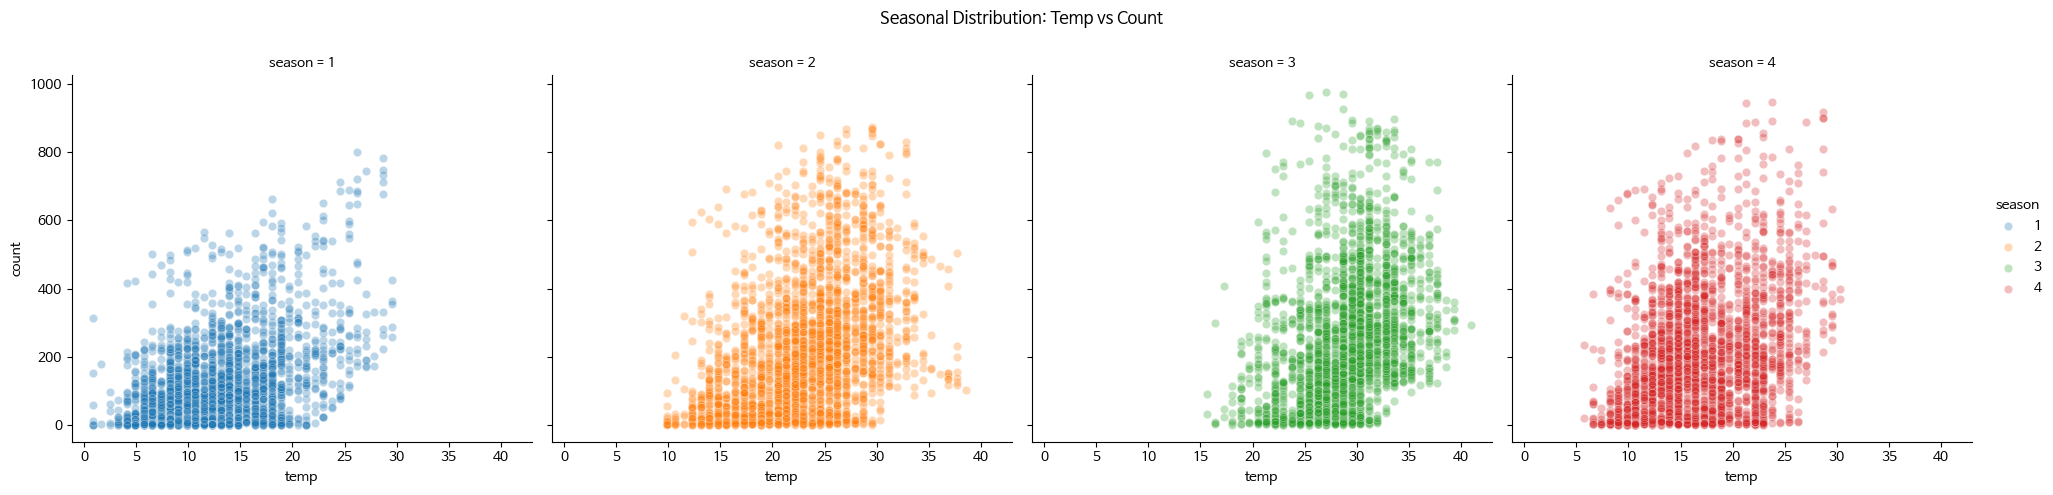

In [196]:
# season별 분포
g = sns.FacetGrid(train, col="season", hue="season", height=5)
g.map(sns.scatterplot, "temp", "count", alpha=0.3)
g.add_legend()
plt.subplots_adjust(top=0.85)
g.fig.suptitle('Seasonal Distribution: Temp vs Count')
plt.show()

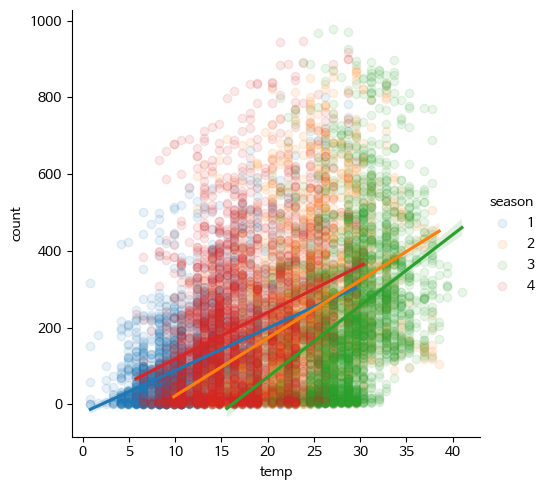

In [197]:
# 계절과 온도가 대여량에 미치는 영향
sns.lmplot(data=train, x='temp', y='count', hue='season', scatter_kws={'alpha':0.1})
plt.show()

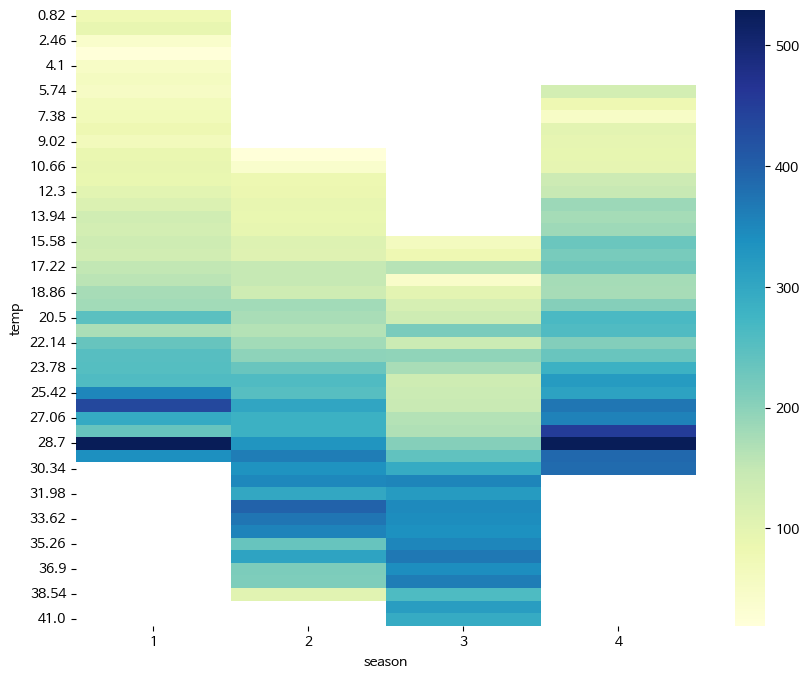

In [198]:
# 온도와 계절 조합별 평균 대여량 히트맵
pivot = train.pivot_table(index='temp', columns='season', values='count', aggfunc='mean')
plt.figure(figsize=(10, 8))
sns.heatmap(pivot, annot=False, cmap='YlGnBu')
plt.show()

In [199]:
# season과 month의 관계를 표로 나타내기
check_table_s = pd.crosstab(train['season'], train['month'])
check_table_s

month,1,2,3,4,5,6,7,8,9,10,11,12
season,,,,,,,,,,,,
1,884,901,901,0,0,0,0,0,0,0,0,0
2,0,0,0,909,912,912,0,0,0,0,0,0
3,0,0,0,0,0,0,912,912,909,0,0,0
4,0,0,0,0,0,0,0,0,0,911,911,912


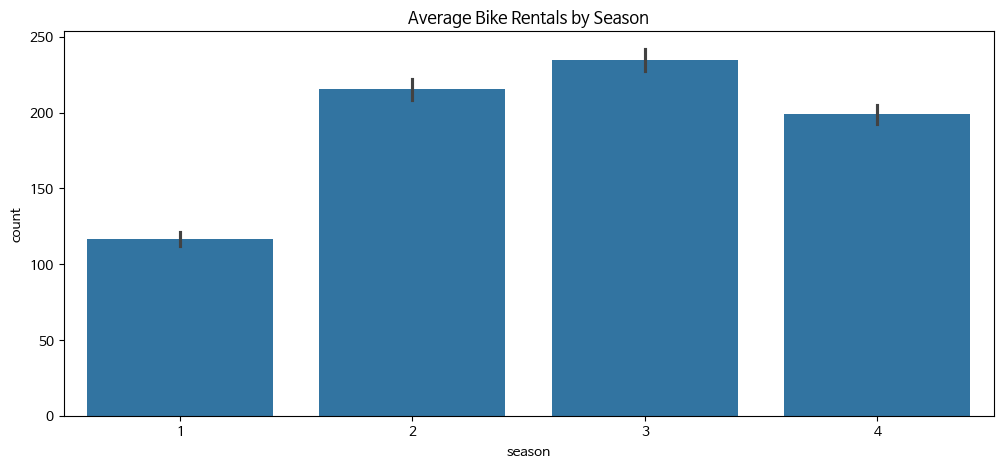

In [200]:
# season 평균 대여량 시각화
plt.figure(figsize=(12, 5))
sns.barplot(data=train, x='season', y='count')
plt.title('Average Bike Rentals by Season')
plt.show()

## temp/atemp 처리

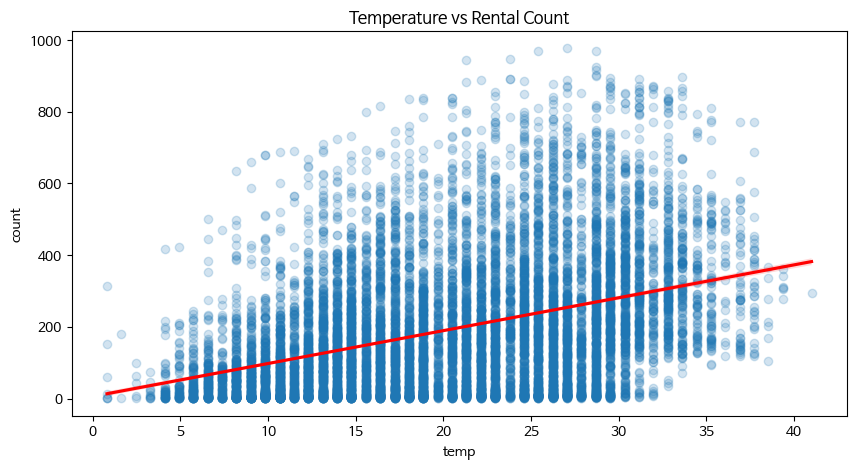

In [201]:
# 온도와 대여량의 관계 (산점도 + 회귀선)
plt.figure(figsize=(10, 5))
sns.regplot(data=train, x='temp', y='count', scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('Temperature vs Rental Count')
plt.show()

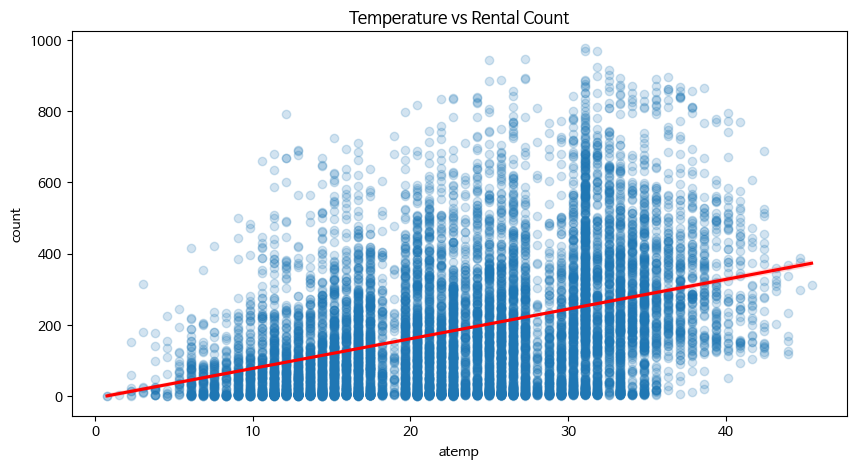

In [202]:
# 체감온도와 대여량의 관계
plt.figure(figsize=(10, 5))
sns.regplot(data=train, x='atemp', y='count', scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('Temperature vs Rental Count')
plt.show()

###
- 회귀선이 우상향 직선 : 기온이 올라갈 수록 대여량이 증가(너무 더운 날씨는 아니지만 어느 정도 온화한 날씨에 많이 대여)
- 35도 이상으로 더워지면 소폭 감소하는 경향
- 더운 날씨에는 대여량이 줄어든다 = 직선만으로는 확인하기 어려움 -> 다중 회귀(곡선) 검토 필요
- 선형 회귀선은 기온 상승에 따른 수요 증가를 잘 보여주지만, 폭염 구간에서의 수요 감소 패턴까지는 반영하지 못하는 한계가 있음.
- 향후 다항 회귀를 통해 이 곡선 패턴을 더 정교하게 학습시킬 필요가 있어 보임.

In [203]:
# 기온과 체감 온도의 영향은 너무 유사함
# 둘 중 뭘 살릴지 확인하기 위해 상관계수 확인
corr = train[['temp', 'atemp', 'count']].corr()
corr

,temp,atemp,count
temp,1.000000,0.984948,0.394454
atemp,0.984948,1.000000,0.389784
count,0.394454,0.389784,1.000000


In [204]:
# 상관계수가 더 낮고 중복되는 atemp 삭제
train = train.drop(['atemp'], axis=1)
train.head()

,datetime,season,holiday,workingday,weather,temp,humidity,windspeed,casual,registered,count,year,month,day,hour,dayofweek
0,2011-01-01 00:00:00,1,0,0,1,9.84,81,0.0,3,13,16,2011,1,1,0,Sat
1,2011-01-01 01:00:00,1,0,0,1,9.02,80,0.0,8,32,40,2011,1,1,1,Sat
2,2011-01-01 02:00:00,1,0,0,1,9.02,80,0.0,5,27,32,2011,1,1,2,Sat
3,2011-01-01 03:00:00,1,0,0,1,9.84,75,0.0,3,10,13,2011,1,1,3,Sat
4,2011-01-01 04:00:00,1,0,0,1,9.84,75,0.0,0,1,1,2011,1,1,4,Sat


In [205]:
test = test.drop(['atemp'], axis=1)
test.head()

,datetime,season,holiday,workingday,weather,temp,humidity,windspeed,year,month,day,hour,dayofweek
0,2011-01-20 00:00:00,1,0,1,1,10.66,56,26.0027,2011,1,20,0,Thu
1,2011-01-20 01:00:00,1,0,1,1,10.66,56,0.0000,2011,1,20,1,Thu
2,2011-01-20 02:00:00,1,0,1,1,10.66,56,0.0000,2011,1,20,2,Thu
3,2011-01-20 03:00:00,1,0,1,1,10.66,56,11.0014,2011,1,20,3,Thu
4,2011-01-20 04:00:00,1,0,1,1,10.66,56,11.0014,2011,1,20,4,Thu


In [206]:
# 시각화를 위한 데이터 복제 (원본 및 모델링 데이터 오염 방지)
df_eda = X.copy()
df_eda['count'] = y

# 파생 변수 생성 (Feature Engineering)
# 출퇴근 시간대 (아침 7~9시, 저녁 17~19시)
df_eda['is_rush_hour'] = df_eda['hour'].apply(lambda x: 1 if x in [7, 8, 9, 17, 18, 19] else 0)

# 출퇴근 시간 + 날씨 조합 (시각화 시 범례 직관성을 위해 문자열로 결합)
df_eda['rush_weather'] = df_eda['is_rush_hour'].astype(str) + '_W' + df_eda['weather'].astype(str)

# 온도(temp) 커스텀 구간화 (5구간)
# 경계값: ~10, ~20, ~30, ~40, 40~
temp_bins = [-np.inf, 10, 20, 30, 40, np.inf]
temp_labels = ['Cold', 'Mild', 'Warm', 'Hot', 'Extreme Hot']
df_eda['temp_band'] = pd.cut(df_eda['temp'], bins=temp_bins, labels=temp_labels)

# 습도(humidity) 커스텀 구간화 (3구간)
# 경계값: ~30, ~60, 61~
"""
https://www.hu-master.com/humidity-in-daily-life/#:~:text=%EC%83%81%EC%98%A8%EC%97%90%EC%84%9C%20%EC%8A%B5%EB%8F%84%EA%B0%80%2070,80%25%20%EC%9D%B4%EC%83%81%EC%9D%B4%EB%A9%B4%20%EB%B0%9C%EC%83%9D%ED%95%A9%EB%8B%88%EB%8B%A4.
"""
humid_bins = [-np.inf, 30, 60, np.inf]
humid_labels = ['Dry', 'Normal', 'Humid']
df_eda['humidity_band'] = pd.cut(df_eda['humidity'], bins=humid_bins, labels=humid_labels)

# 3. 풍속(windspeed) 커스텀 구간화 (5구간)
# 경계값: ~15, ~20, ~30, ~40, 41~
"""
https://www.data.jma.go.jp/multi/cyclone/cyclone_wind_advisory.html?lang=kr
"""
wind_bins = [-np.inf, 15, 20, 30, 40, np.inf]
wind_labels = ['Low', 'Medium', 'High', 'Very High', 'Strong']
df_eda['windspeed_band'] = pd.cut(df_eda['windspeed'], bins=wind_bins, labels=wind_labels)

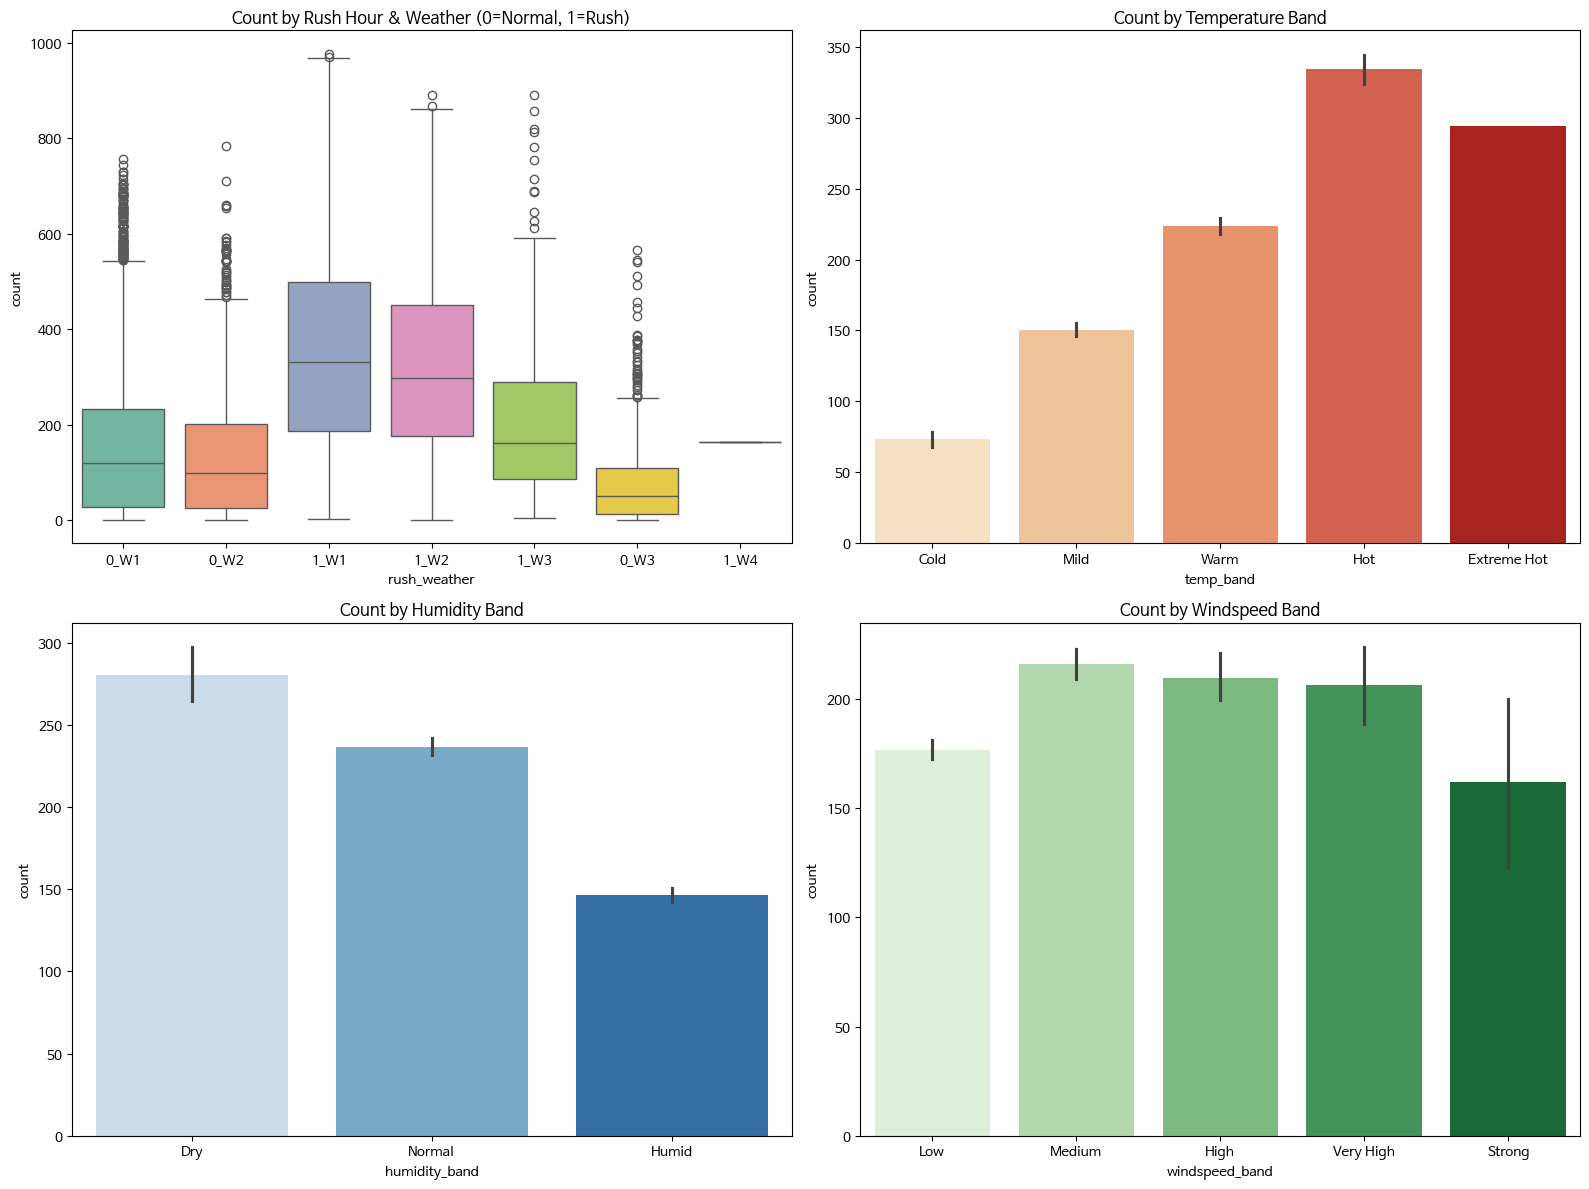

In [207]:
# 서브플롯 시각화 세팅
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# [그래프 1] 출퇴근 여부와 날씨의 조합에 따른 대여량
sns.boxplot(data=df_eda, x='rush_weather', y='count', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Count by Rush Hour & Weather (0=Normal, 1=Rush)')

# [그래프 2] 온도 구간에 따른 대여량
sns.barplot(data=df_eda, x='temp_band', y='count', ax=axes[0, 1], palette='OrRd')
axes[0, 1].set_title('Count by Temperature Band')

# [그래프 3] 습도 구간에 따른 대여량
sns.barplot(data=df_eda, x='humidity_band', y='count', ax=axes[1, 0], palette='Blues')
axes[1, 0].set_title('Count by Humidity Band')

# [그래프 4] 풍속 구간에 따른 대여량
sns.barplot(data=df_eda, x='windspeed_band', y='count', ax=axes[1, 1], palette='Greens')
axes[1, 1].set_title('Count by Windspeed Band')

plt.tight_layout()
plt.show()

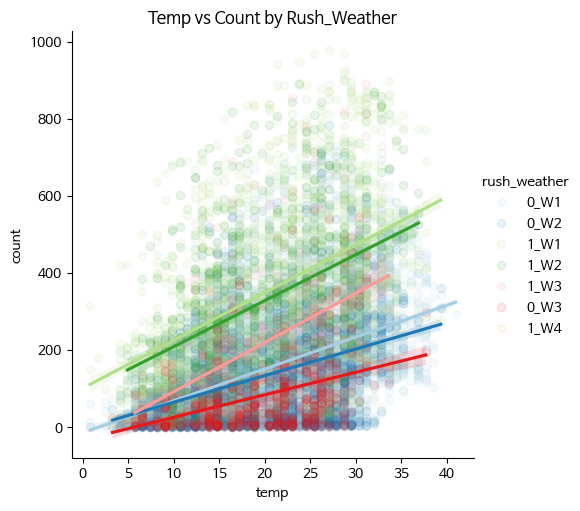

In [208]:
# rush_weather 조합별로 온도가 대여량에 미치는 영향 확인
sns.lmplot(data=df_eda, x='temp', y='count', hue='rush_weather', scatter_kws={'alpha':0.1}, palette='Paired')
plt.title('Temp vs Count by Rush_Weather')
plt.show()

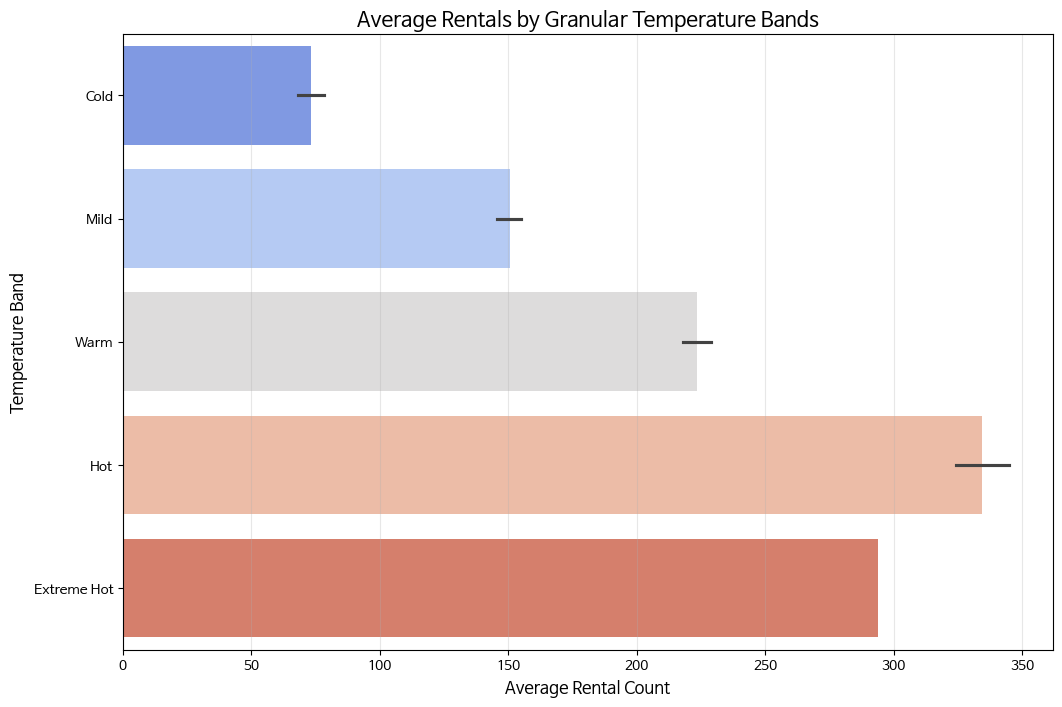

In [209]:
# 온도 구간별 평균 대여량 시각화
plt.figure(figsize=(12, 8))
sns.barplot(data=df_eda, x='count', y='temp_band', palette='coolwarm')

plt.title('Average Rentals by Granular Temperature Bands', fontsize=15)
plt.xlabel('Average Rental Count', fontsize=12)
plt.ylabel('Temperature Band', fontsize=12)
plt.grid(axis='x', alpha=0.3)
plt.show()

# 모델링 사전 준비

In [210]:
# 데이터 일치 재확인
ignore = {'casual', 'registered', 'count'}

# 2. 비교 후 결과만 출력 (True / False)
print((set(train.columns) - ignore) == set(test.columns))

True


In [211]:
# 머신러닝 도구 (Scikit-learn) 부르기
from sklearn.model_selection import train_test_split # 데이터 분리
from sklearn.linear_model import LinearRegression    # 선형 회귀
from sklearn.preprocessing import PolynomialFeatures # 다항 회귀 (특성 변환)
from sklearn.metrics import mean_squared_log_error, mean_squared_error   # MSLE 계산, MSE 계산

In [212]:
# 사용할 변수를 한정하고 머신러닝용 훈련/검증 데이터 분리

# 'dayofweek' 컬럼을 원-핫 인코딩하여 숫자로 변환
train = pd.get_dummies(train, columns=['dayofweek'], drop_first=False)
test = pd.get_dummies(test, columns=['dayofweek'], drop_first=False)

# 변경된 'dayofweek' 컬럼들을 features_base에 반영
# 기존 'dayofweek'는 제거하고 새로 생성된 컬럼들을 추가
new_dayofweek_cols = [col for col in train.columns if col.startswith('dayofweek_')]
features_base = ['season', 'holiday', 'workingday', 'weather', 'temp',
            'humidity', 'windspeed', 'year', 'month', 'hour'] + new_dayofweek_cols

X = train[features_base]
y = train['count']

# 훈련 데이터와 검증 데이터 분리 (8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"학습용: {X_train.shape}, 검증용: {X_test.shape}")

학습용: (8708, 17), 검증용: (2178, 17)


In [214]:
train.shape

(10886, 22)

In [215]:
test.shape

(6493, 19)

# 1차 모델링

In [216]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [217]:
# 예측 수행
y_pred = model.predict(X_test)

# 음수 예측값 처리 (대여량은 음수가 될 수 없음)
y_pred[y_pred < 0] = 0

# 평가 지표 계산
# RMSE (Root Mean Squared Error)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE (Base Model): {rmse:.4f}")

# RMSLE (Root Mean Squared Log Error) - 대회 평가 지표
# RMSLE를 계산하기 위해 로그 변환을 수행하기 전에 0인 값을 1로 대체하여 log(0) 오류를 방지
rmsle = np.sqrt(mean_squared_log_error(y_test, y_pred))
print(f"RMSLE (Base Model): {rmsle:.4f}")

RMSE (Base Model): 140.6038
RMSLE (Base Model): 1.3092


In [218]:
# 로그 변환 (np.log1p는 log(1+x)와 같음)
y_train_log = np.log1p(y_train)

# 로그 변환된 값으로 모델 학습
model.fit(X_train, y_train_log)

# 예측 수행 (결과값도 로그 형태)
preds_log = model.predict(X_test)

# 다시 원래 단위로 되돌리기 (지수 변환)
preds_exp = np.expm1(preds_log)

# 음수 처리 및 RMSLE 계산
preds_exp[preds_exp < 0] = 0
rmsle_new = np.sqrt(mean_squared_log_error(y_test, preds_exp))
print(f"Log Transformed RMSLE: {rmsle_new:.5f}")

Log Transformed RMSLE: 1.02508


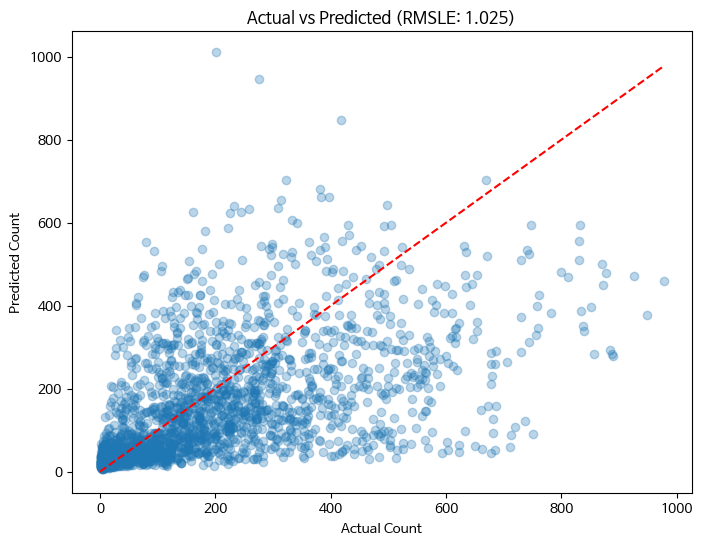

In [219]:
# 예측값과 실제값 비교 시각화
plt.figure(figsize=(8, 6))
# 실제값(y_val)과 로그 변환 후 되돌린 예측값(preds_exp) 비교
plt.scatter(y_test, preds_exp, alpha=0.3)
plt.plot([0, y_test.max()], [0, y_test.max()], 'r--') # 45도 가이드 라인
plt.xlabel('Actual Count')
plt.ylabel('Predicted Count')
plt.title('Actual vs Predicted (RMSLE: 1.025)')
plt.show()

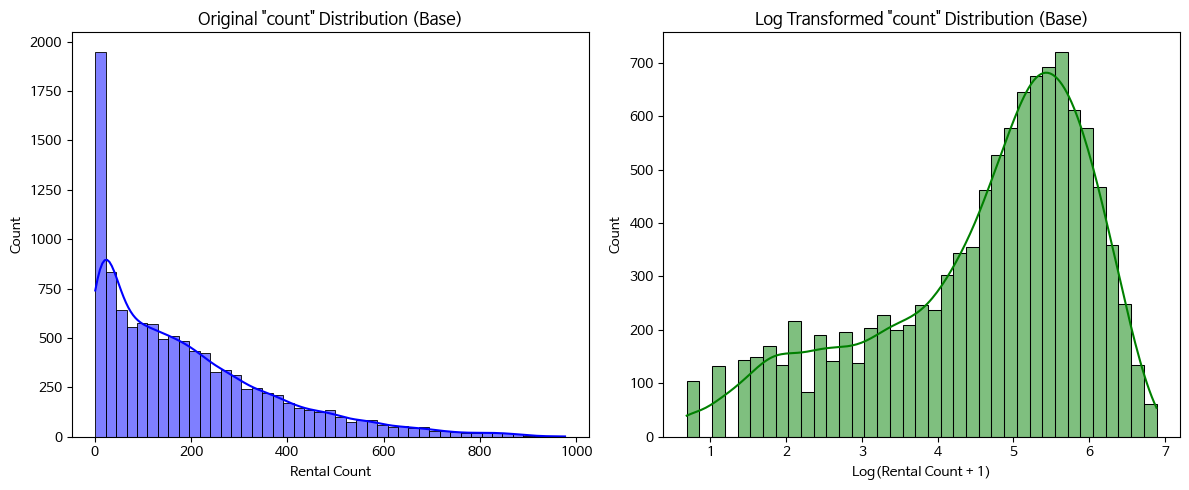

In [220]:
# 시각화 영역 설정 (1행 2열)
fig, ax = plt.subplots(figsize=(12, 5), ncols=2)

# [왼쪽] 원래 타겟값 분포 (y_base 활용)
sns.histplot(y, kde=True, ax=ax[0], color='blue')
ax[0].set_title('Original "count" Distribution (Base)')
ax[0].set_xlabel('Rental Count')

# [오른쪽] 로그 변환 후 타겟값 분포
y_train_log = np.log1p(y)
sns.histplot(y_train_log, kde=True, ax=ax[1], color='green')
ax[1].set_title('Log Transformed "count" Distribution (Base)')
ax[1].set_xlabel('Log(Rental Count + 1)')

plt.tight_layout()
plt.show()

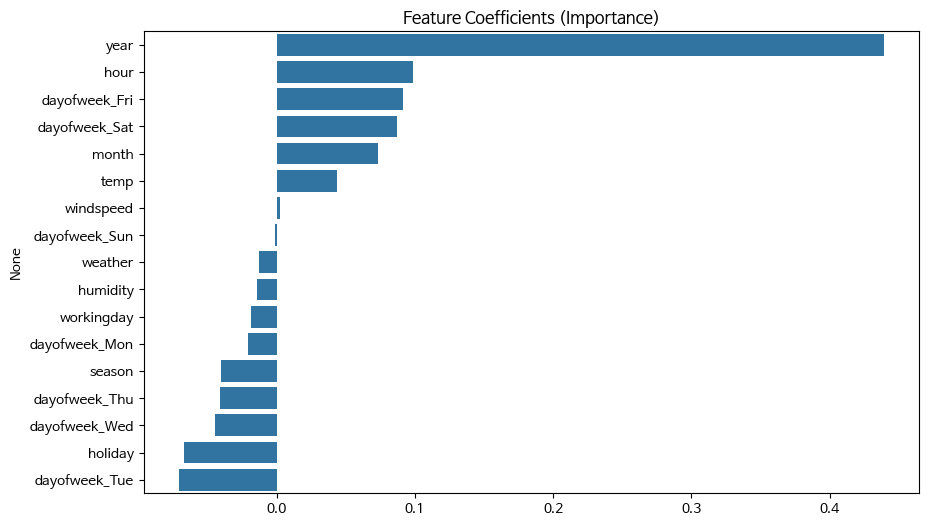

In [221]:
# 모델의 회귀 계수(coef_) 추출
coef_series = pd.Series(data=model.coef_, index=features_base).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=coef_series.values, y=coef_series.index)
plt.title('Feature Coefficients (Importance)')
plt.show()

# 2차 모델링

In [222]:
# 1차 모델링에서 만든 깨끗한 X와 동일한 조건의 test 데이터를 활용
test_base = test[features_base]

# 2차 모델링용 추가 원-핫 인코딩 대상 지정
cat_cols = ['season', 'weather', 'hour', 'month', 'year']

# 원본 train 대신, 준비된 X와 test_base에 바로 인코딩 적용
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)
test_encoded = pd.get_dummies(test_base, columns=cat_cols, drop_first=True)

# train(X_encoded) 기준으로 test 컬럼 동기화 (빈 곳은 0으로 채움)
X_encoded, test_encoded = X_encoded.align(test_encoded, join='left', axis=1, fill_value=0)

# 2차 모델링을 위한 훈련/검증 데이터 재분리 (기존 y는 그대로 사용)
X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f"2차 학습용: {X_train_v2.shape}, 2차 검증용: {X_test_v2.shape}")
print(f"제출용 Test 데이터: {test_encoded.shape}")
print(f"컬럼 완벽 일치 여부: {set(X_encoded.columns) == set(test_encoded.columns)}")

2차 학습용: (8708, 53), 2차 검증용: (2178, 53)
제출용 Test 데이터: (6493, 53)
컬럼 완벽 일치 여부: True


In [223]:
# 2차 모델 객체 독립적으로 생성
model_v2 = LinearRegression()
# 2차 데이터와 로그 변환된 타겟값으로 학습
model_v2.fit(X_train_v2, y_train_v2_log)

LinearRegression()

In [224]:
# 1차 때 성능이 좋았던 로그 변환(np.log1p) 방식을 그대로 적용
y_train_v2_log = np.log1p(y_train_v2)

# 타겟 변수 로그 변환 (2차 학습용 타겟)
y_train_v2_log = np.log1p(y_train_v2)

# 로그 변환된 값으로 2차 모델 학습
model_v2.fit(X_train_v2, y_train_v2_log)

# 2차 검증 데이터로 예측 수행 (결과값은 로그 형태)
preds_log_v2 = model_v2.predict(X_test_v2)

# 다시 원래 단위로 되돌리기 (지수 변환)
preds_exp_v2 = np.expm1(preds_log_v2)

# 음수 처리 및 최종 RMSLE 계산
preds_exp_v2[preds_exp_v2 < 0] = 0
rmsle_v2 = np.sqrt(mean_squared_log_error(y_test_v2, preds_exp_v2))

print(f"2차 모델(v2) Log Transformed RMSLE: {rmsle_v2:.5f}")

2차 모델(v2) Log Transformed RMSLE: 0.58097


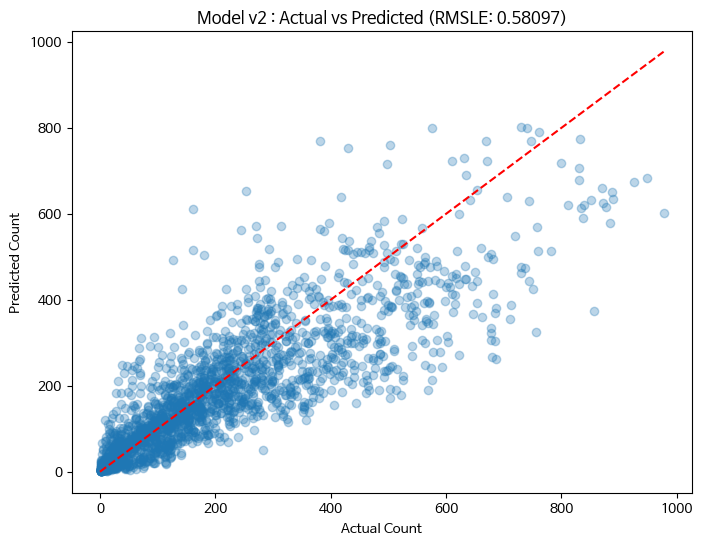

In [225]:
# 예측값과 실제값 비교 시각화
plt.figure(figsize=(8, 6))
# 실제값(y_val)과 로그 변환 후 되돌린 예측값(preds_exp) 비교
plt.scatter(y_test_v2, preds_exp_v2, alpha=0.3)
plt.plot([0, y_test_v2.max()], [0, y_test.max()], 'r--') # 45도 가이드 라인
plt.xlabel('Actual Count')
plt.ylabel('Predicted Count')
plt.title(f'Model v2 : Actual vs Predicted (RMSLE: {rmsle_v2:.5f})')
plt.show()

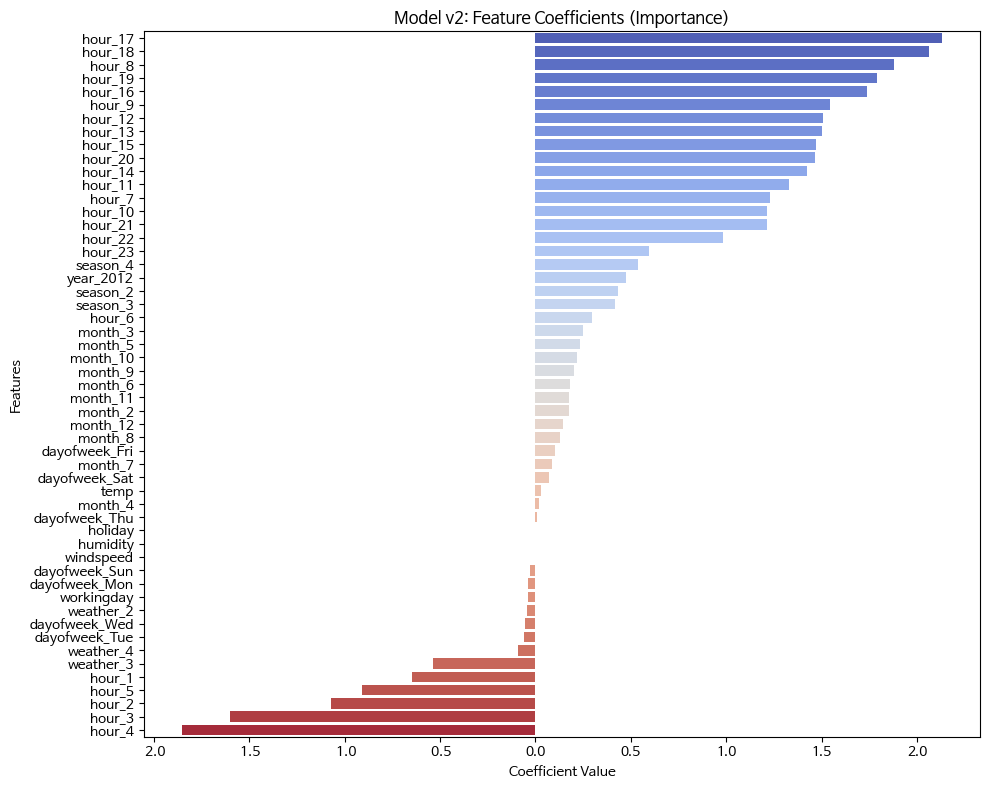

In [226]:
# 모델의 회귀 계수(coef_) 추출
# 2차 모델에 실제로 들어간 컬럼명(X_train_v2.columns)을 인덱스로 사용
coef_series_v2 = pd.Series(data=model_v2.coef_, index=X_train_v2.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=coef_series_v2.values, y=coef_series_v2.index, palette='coolwarm')

plt.title('Model v2: Feature Coefficients (Importance)')
plt.xlabel('Coefficient Value')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# 오차 분석

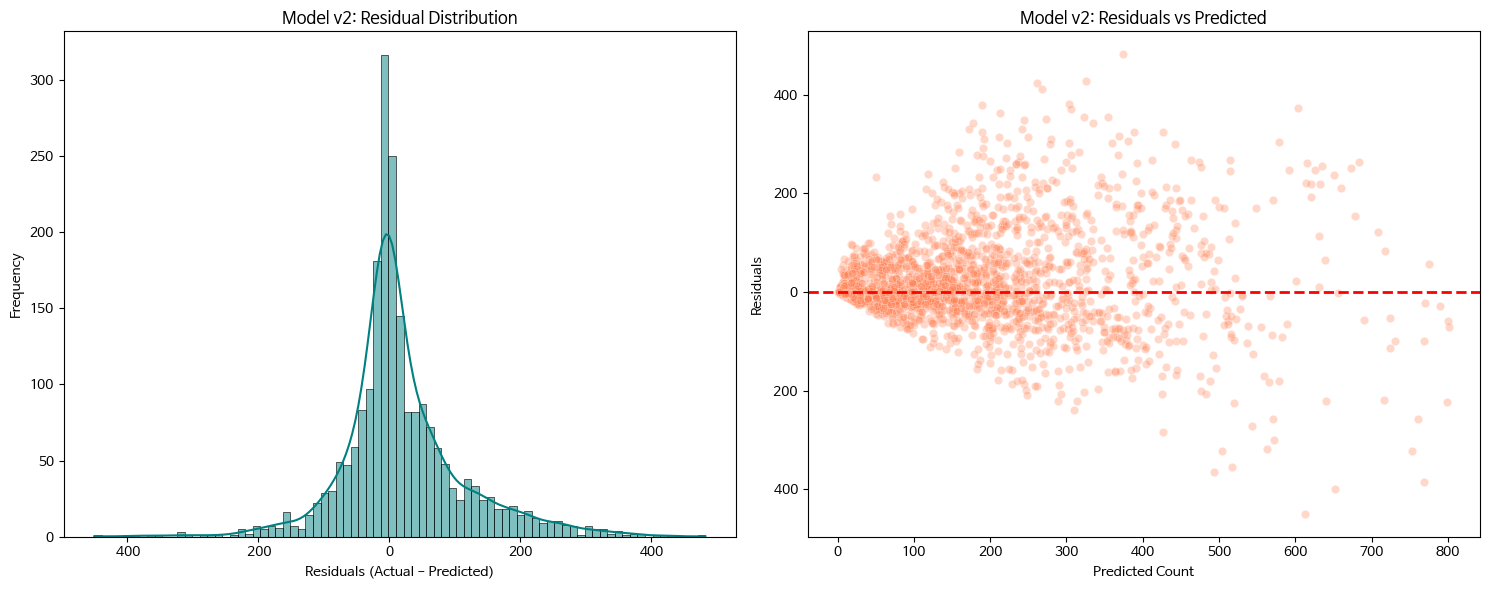

In [227]:
# 1. 잔차(Residual) 계산: 실제 렌탈량 - 예측 렌탈량
# 양수면 과소예측(Under-prediction), 음수면 과대예측(Over-prediction)을 의미합니다.
residuals = y_test_v2 - preds_exp_v2

# 서브플롯
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 잔차 분포도 (Histogram)
# 오차가 0을 중심으로 예쁜 종 모양(정규분포)을 그리는지 확인합니다.
sns.histplot(residuals, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Model v2: Residual Distribution')
axes[0].set_xlabel('Residuals (Actual - Predicted)')
axes[0].set_ylabel('Frequency')

# [그래프 2] 잔차도 (Residual Plot) - 예측값 vs 잔차
# 예측값이 커질수록 오차가 무작위로 퍼져 있는지, 아니면 특정 패턴(깔때기 모양 등)이 있는지 확인합니다.
sns.scatterplot(x=preds_exp_v2, y=residuals, alpha=0.3, color='coral', ax=axes[1])
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2) # 완벽한 예측(오차 0) 기준선
axes[1].set_title('Model v2: Residuals vs Predicted')
axes[1].set_xlabel('Predicted Count')
axes[1].set_ylabel('Residuals')

plt.tight_layout()
plt.show()

In [228]:
# 1. 인코딩된 검증 데이터(X_test_v2) 복사하여 분석용 DF 생성
error_analysis = X_test_v2.copy()
error_analysis['actual'] = y_test_v2
error_analysis['predict'] = preds_exp_v2

# 2. 오차(절댓값) 계산 및 상위 10개 추출
error_analysis['error'] = abs(error_analysis['actual'] - error_analysis['predict'])
top_errors = error_analysis.sort_values(by='error', ascending=False).head(10)

# 3. 보기 좋게 출력하기 위한 컬럼 필터링 (지뢰 제거 완료!)
# 원본 train을 참조하다 에러가 나는 것을 방지하기 위해,
# 이미 모든 정보가 담겨있는 top_errors 안에서 해석에 필요한 핵심 변수들만 직관적으로 뽑아냅니다.
# (원-핫 인코딩된 컬럼들도 포함해서 모델이 뭘 보고 헷갈렸는지 파악)

# 보고 싶은 핵심 연속형 변수들
core_cols = ['temp', 'humidity', 'windspeed', 'workingday', 'holiday']

# 추가로 확인하고 싶은 원-핫 인코딩 범주형 변수들 (예: 날씨, 시간, 요일)
# startswith를 써서 관련된 컬럼만 스마트하게 싹 긁어옵니다.
cat_cols_to_view = [col for col in top_errors.columns if col.startswith(('weather_', 'hour_', 'dayofweek_'))]

# 4. 타겟 정보(실제, 예측, 오차) + 연속형 변수 + 범주형 변수 병합하여 출력
summary_cols = ['actual', 'predict', 'error'] + core_cols + cat_cols_to_view
error_summary = top_errors[summary_cols]

# 소수점 보기 좋게 반올림해서 출력 (파이썬다운 디테일)
error_summary.round(1)

,actual,predict,error,temp,humidity,windspeed,workingday,holiday,dayofweek_Fri,dayofweek_Mon,dayofweek_Sat,dayofweek_Sun,dayofweek_Thu,dayofweek_Tue,dayofweek_Wed,weather_2,weather_3,weather_4,hour_1,hour_2,hour_3,hour_4,hour_5,hour_6,hour_7,hour_8,hour_9,hour_10,hour_11,hour_12,hour_13,hour_14,hour_15,hour_16,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23
9536,856,373.7,482.3,23.0,60,17.0,1,0,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
9071,162,612.0,450.0,31.2,58,17.0,0,0,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
8528,755,326.2,428.8,31.2,66,39.0,1,0,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
6726,686,261.6,424.4,24.6,60,7.0,0,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
6728,679,267.9,411.1,26.2,53,9.0,0,0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
8337,253,652.4,399.4,32.0,62,7.0,0,0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
8720,382,768.2,386.2,33.6,46,17.0,0,0,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
6864,684,303.0,381.0,18.0,72,7.0,1,0,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
7798,569,189.0,380.0,19.7,77,20.0,1,0,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
9345,977,602.7,374.3,27.1,44,17.0,1,0,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False


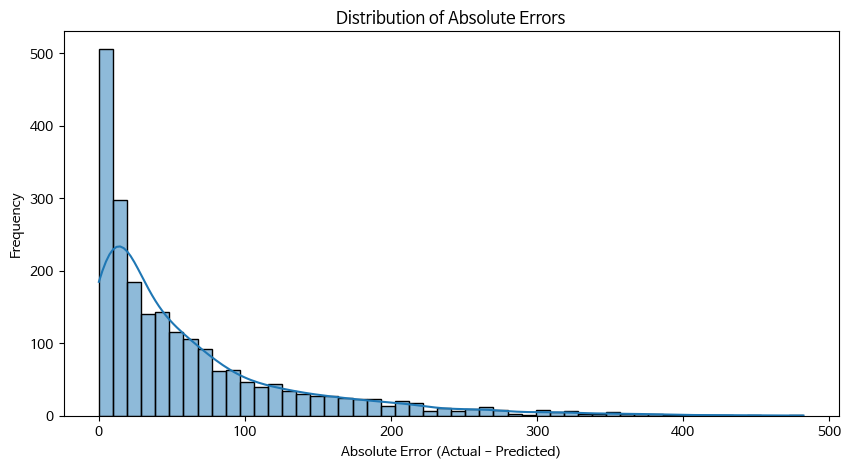

In [229]:
# 오차 분포 시각화
plt.figure(figsize=(10, 5))
sns.histplot(error_analysis['error'], bins=50, kde=True)
plt.title('Distribution of Absolute Errors')
plt.xlabel('Absolute Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.show()

# 경사부스팅 회귀

In [230]:
from xgboost import XGBRegressor

# 타겟값 로그 변환
y_train_v2_log = np.log1p(y_train_v2)
y_test_v2_log = np.log1p(y_test_v2) # 조기 종료 검증(eval_set)에 쓰기 위해 로그 변환

# 모델 정의
model_xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,              # 트리의 최대 깊이 (과적합 방지)
    random_state=42,
    early_stopping_rounds=50
)


In [231]:
# 모델 학습
model_xgb.fit(
    X_train_v2, y_train_v2_log,
    eval_set=[(X_test_v2, y_test_v2_log)],
    verbose=100
)

# 검증 데이터 예측 수행 및 원래 단위로 복원(지수 변환)
preds_xgb_log = model_xgb.predict(X_test_v2)
preds_xgb_exp = np.expm1(preds_xgb_log)

# 음수 처리 (대여량은 0 미만이 될 수 없음)
preds_xgb_exp[preds_xgb_exp < 0] = 0

# 6. 최종 평가 지표 (RMSLE) 계산
rmsle_xgb = np.sqrt(mean_squared_log_error(y_test_v2, preds_xgb_exp))
print(f"3차 모델(XGBoost) RMSLE_v3: {rmsle_xgb:.5f}")

[0]	validation_0-rmse:1.38768
[100]	validation_0-rmse:0.50362
[200]	validation_0-rmse:0.41486
[300]	validation_0-rmse:0.39084
[400]	validation_0-rmse:0.37238
[500]	validation_0-rmse:0.36481
[600]	validation_0-rmse:0.36006
[700]	validation_0-rmse:0.35580
[800]	validation_0-rmse:0.35251
[900]	validation_0-rmse:0.35010
[999]	validation_0-rmse:0.34813
3차 모델(XGBoost) RMSLE_v3: 0.34811


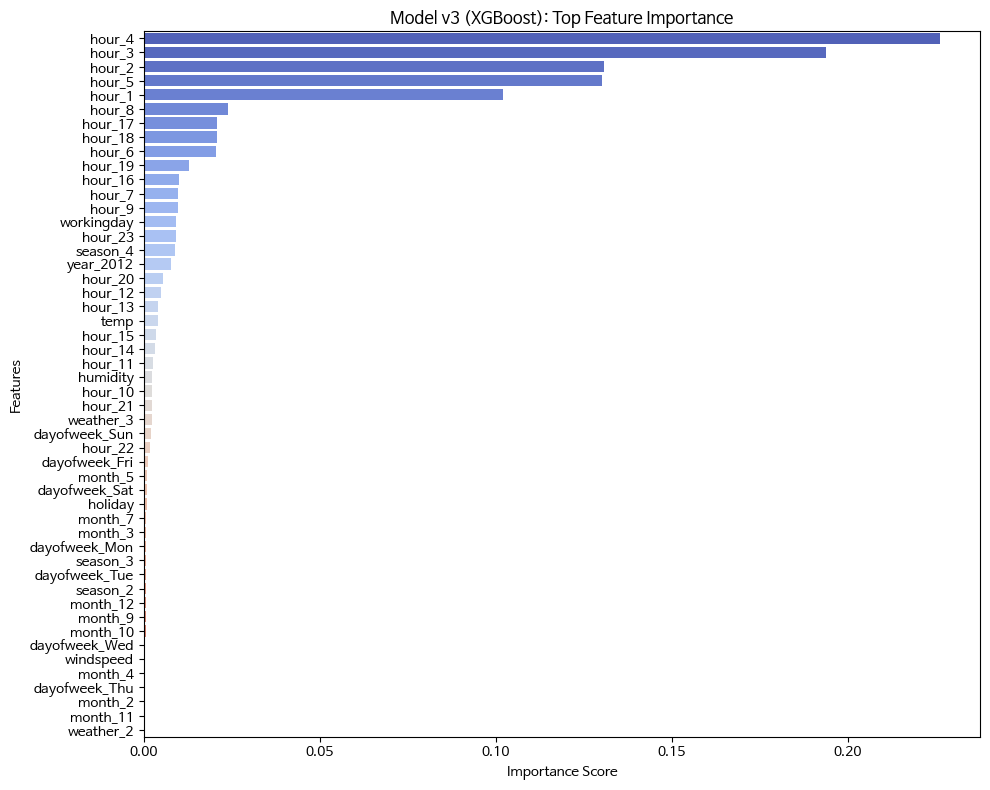

In [234]:
# XGBoost 모델에서 변수 중요도(feature_importances_) 추출
importance_df = pd.DataFrame({
    'feature': X_train_v2.columns,
    'importance': model_xgb.feature_importances_
}).sort_values(by='importance', ascending=False)

# 너무 많으면 보기 힘드니, 모델에 가장 큰 영향을 준 상위 20개만 컷팅
top_50_features = importance_df.head(50)

# 깔끔하고 직관적인 바 차트로 시각화
plt.figure(figsize=(10, 8))
# 중요도가 높은 순으로 진하게 표현되는 viridis 팔레트 사용
sns.barplot(data=top_50_features, x='importance', y='feature', palette='coolwarm')

plt.title('Model v3 (XGBoost): Top Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [236]:
!pip install shap

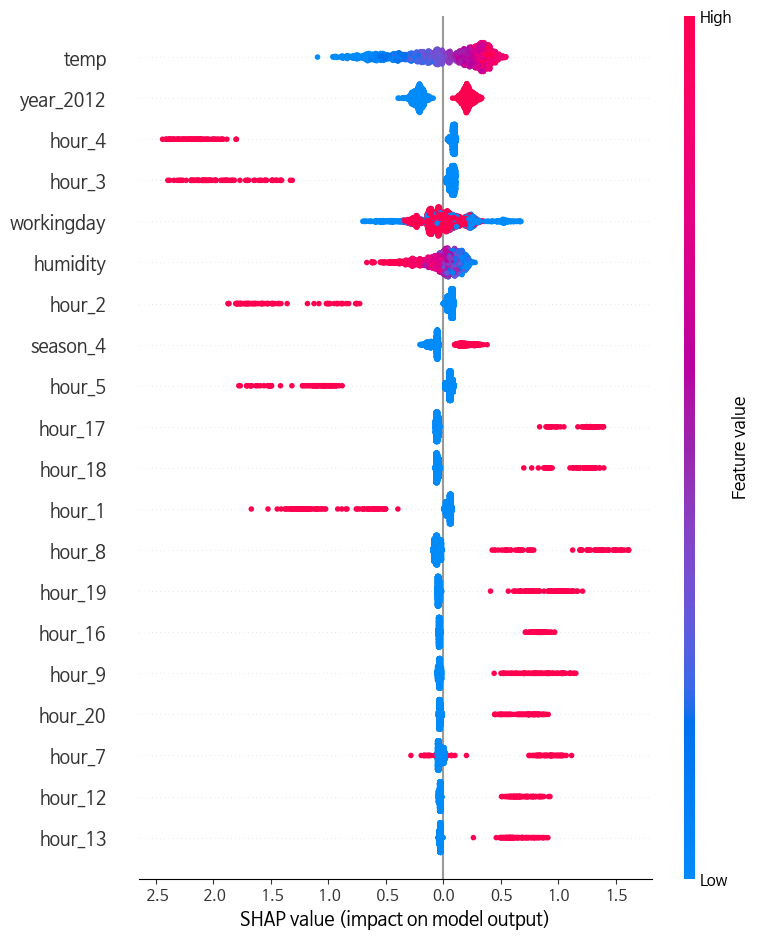

In [237]:
import shap

# 1. 트리 모델 전용 Explainer 객체 생성
# (우리의 자랑스러운 3차 XGBoost 모델을 통째로 집어넣습니다)
explainer = shap.TreeExplainer(model_xgb)

# 2. 검증 데이터(X_test_v2)를 바탕으로 SHAP Value 계산
# (전체 데이터로 하면 너무 오래 걸리니, 검증 데이터로만 뽑는 것이 세련된 국룰입니다)
shap_values = explainer.shap_values(X_test_v2)

# 3. 대망의 SHAP Summary Plot 시각화
# 복잡한 matplotlib 설정? 필요 없습니다. 이 한 줄이 다 알아서 해줍니다.
shap.summary_plot(shap_values, X_test_v2)

# 사용자 그룹 분리 예측

In [238]:
# 타겟값 추출
y_casual_train = train.loc[X_train_v2.index, 'casual']
y_casual_test = train.loc[X_test_v2.index, 'casual']

y_reg_train = train.loc[X_train_v2.index, 'registered']
y_reg_test = train.loc[X_test_v2.index, 'registered']

# 각각 로그 변환
y_casual_train_log, y_casual_test_log = np.log1p(y_casual_train), np.log1p(y_casual_test)
y_reg_train_log, y_reg_test_log = np.log1p(y_reg_train), np.log1p(y_reg_test)


In [239]:
# 모델 정의 (각각의 타겟을 위한 2개의 독립된 XGBoost)
xgb_params = {
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'max_depth': 6,
    'random_state': 42,
    'early_stopping_rounds': 50
}
model_casual = XGBRegressor(**xgb_params)
model_reg = XGBRegressor(**xgb_params)

In [240]:
# Casual 모델 학습 및 예측
model_casual.fit(X_train_v2, y_casual_train_log, eval_set=[(X_test_v2, y_casual_test_log)], verbose=False)
preds_casual_exp = np.expm1(model_casual.predict(X_test_v2))

# Registered 모델 학습 및 예측
model_reg.fit(X_train_v2, y_reg_train_log, eval_set=[(X_test_v2, y_reg_test_log)], verbose=False)
preds_reg_exp = np.expm1(model_reg.predict(X_test_v2))

In [241]:
# 두 예측값 합치기 (최종 Count 예측값) 및 음수 처리
preds_final_exp = preds_casual_exp + preds_reg_exp
preds_final_exp[preds_final_exp < 0] = 0

# 최종 성능 평가
rmsle_dual = np.sqrt(mean_squared_log_error(y_test_v2, preds_final_exp))
print(f"그룹 분리 예측(Dual XGBoost) 최종 RMSLE: {rmsle_dual:.5f}")

그룹 분리 예측(Dual XGBoost) 최종 RMSLE: 0.33980


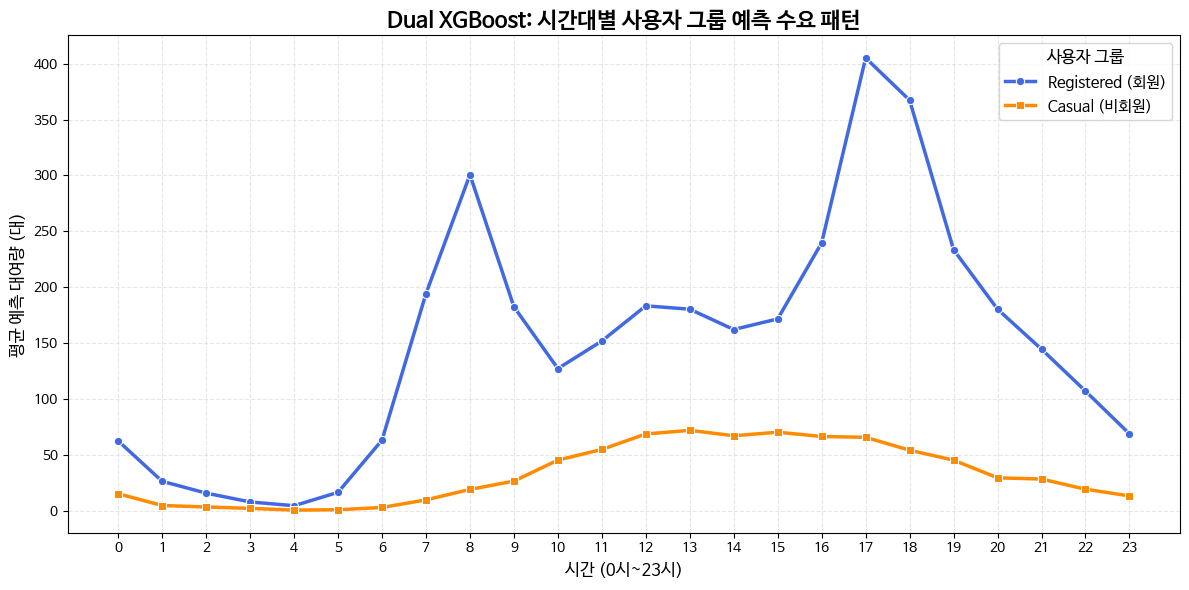

In [242]:
# 시간대별 평균 예측 대여량 비교
df_vis = pd.DataFrame({
    'hour': train.loc[X_test_v2.index, 'hour'],
    'casual_pred': preds_casual_exp,
    'registered_pred': preds_reg_exp
})

# 시간대별 평균 예측량 계산
hourly_group_avg = df_vis.groupby('hour')[['casual_pred', 'registered_pred']].mean().reset_index()

# 시각화
plt.figure(figsize=(12, 6))

# Registered(회원)
sns.lineplot(data=hourly_group_avg, x='hour', y='registered_pred',
             marker='o', label='Registered (회원)', color='royalblue', linewidth=2.5)

# Casual(비회원)
sns.lineplot(data=hourly_group_avg, x='hour', y='casual_pred',
             marker='s', label='Casual (비회원)', color='darkorange', linewidth=2.5)

plt.title('Dual XGBoost: 시간대별 사용자 그룹 예측 수요 패턴', fontsize=16, fontweight='bold')
plt.xlabel('시간 (0시~23시)', fontsize=12)
plt.ylabel('평균 예측 대여량 (대)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(title='사용자 그룹', fontsize=11, title_fontsize=12)
plt.tight_layout()

plt.show()

In [244]:
#
test_casual_log = model_casual.predict(test_encoded)
test_reg_log = model_reg.predict(test_encoded)

# 지수 변환(expm1)으로 원래 스케일 복구 및 음수 처리
test_casual_exp = np.expm1(test_casual_log)
test_reg_exp = np.expm1(test_reg_log)

test_casual_exp[test_casual_exp < 0] = 0
test_reg_exp[test_reg_exp < 0] = 0

# 두 그룹 합치기
final_test_preds = test_casual_exp + test_reg_exp

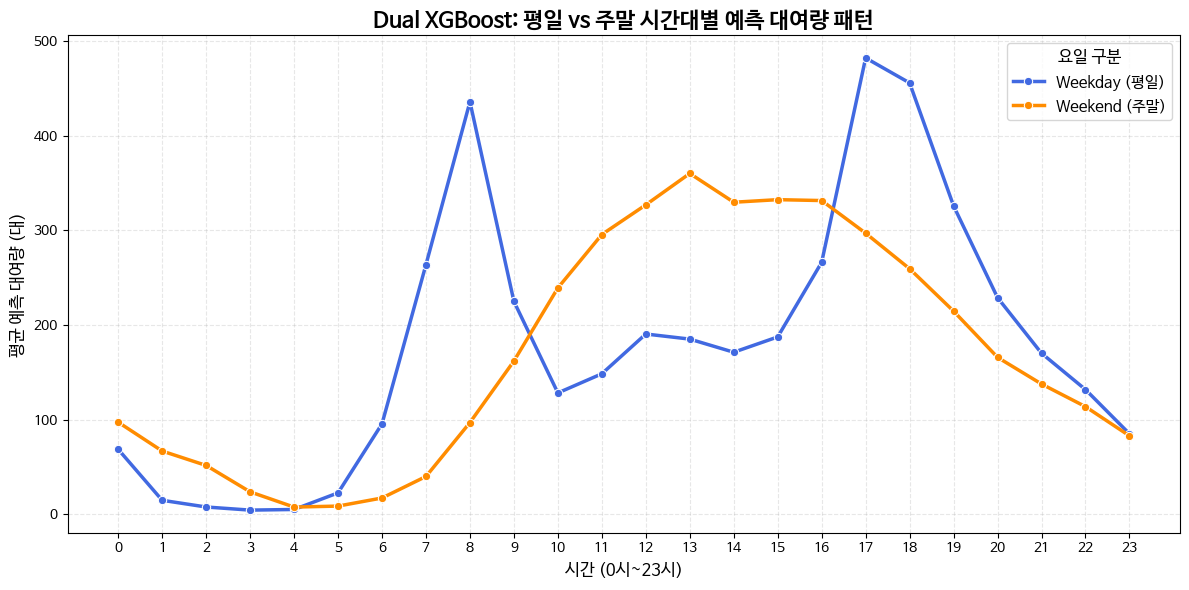

In [245]:
# 평일/주말 시간대별 수요 예측
df_pred_vis = pd.DataFrame()

# 원본 test 데이터의 datetime 파싱
df_pred_vis['datetime'] = pd.to_datetime(test['datetime'])
df_pred_vis['hour'] = df_pred_vis['datetime'].dt.hour
df_pred_vis['dayofweek'] = df_pred_vis['datetime'].dt.dayofweek

# 평일/주말 파생 변수 생성 (0~4: 평일, 5~6: 토/일)
df_pred_vis['is_weekend'] = df_pred_vis['dayofweek'].apply(
    lambda x: 'Weekend (주말)' if x >= 5 else 'Weekday (평일)'
)

# Dual 모델 예측값 매칭
df_pred_vis['count'] = final_test_preds

# 시각화
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_pred_vis, x='hour', y='count', hue='is_weekend',
             marker='o', linewidth=2.5, errorbar=None,
             palette={'Weekday (평일)': 'royalblue', 'Weekend (주말)': 'darkorange'})

plt.title('Dual XGBoost: 평일 vs 주말 시간대별 예측 대여량 패턴', fontsize=16, fontweight='bold')
plt.xlabel('시간 (0시~23시)', fontsize=12)
plt.ylabel('평균 예측 대여량 (대)', fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, alpha=0.3, linestyle='--')
plt.legend(title='요일 구분', fontsize=11, title_fontsize=12)
plt.tight_layout()

plt.show()

In [246]:
# CSV 파일 생성
submission = pd.DataFrame({
    'datetime': test['datetime'],
    'count': final_test_preds
})

In [247]:
submission.to_csv('submission_dual_xgb.csv', index=False)